# 🏗️ Weight Initialization and Gradient Dynamics in Deep Learning

**Learning Objectives:**
- Understand the mathematical and practical importance of weight initialization.
- Diagnose vanishing and exploding gradients by tracking activations and gradient flows in a deep network.
- Learn why setting weights to zero or constant values prevents symmetry breaking.
- Master the theory and formulas behind Xavier (Glorot) and He (Kaiming) initializations.
- Programmatically initialize networks in PyTorch.
- Run a comparative experiment on a classification dataset to observe how initialization strategies directly affect convergence.

**Contents:**
1. Why Initialization Matters (Symmetry Breaking)
2. Pitfalls: Too Small vs. Too Large Weights
3. Xavier (Glorot) Initialization
4. He (Kaiming) Initialization
5. Implementing Initialization in PyTorch
6. Training Comparison: Converging vs. Stalled Networks
7. Summary & Best Practices

## Prerequisites

We will use:
- `numpy` for basic operations and comparisons.
- `matplotlib` for plotting activation and gradient distributions.
- `torch` for building neural networks, tracking gradients, and training.
- `sklearn` for generating a synthetic classification dataset.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

%matplotlib inline

Using device: cpu


## 1) Why Initialization Matters (Symmetry Breaking)

Suppose we have a Multi-Layer Perceptron (MLP). If we initialize all weights to zero or a constant value, what happens during the forward and backward pass?

### The Symmetry Problem

For any layer $l$:
$$z^{[l]} = W^{[l]} a^{[l-1]} + b^{[l]}$$

If all weights in $W^{[l]}$ are initialized to the exact same value (e.g., $0$):
1. **Identical Forward Activations**: Every hidden neuron in a layer will receive the exact same input, compute the same value, and produce the same output: $a_1^{[l]} = a_2^{[l]} = a_3^{[l]} = \dots$
2. **Identical Gradients**: During backpropagation, the gradients with respect to the weights will also be identical.
3. **No Symmetry Breaking**: When weights are updated, they will all change by the same amount. Thus, all neurons in a layer remain identical. The network behaves as if it only has a single neuron per layer, rendering its width useless.

To allow different neurons to learn different features, we **must** break symmetry by initializing weights randomly.

Let's verify this empirically by initializing a PyTorch MLP to all zeros and observing the hidden units.

In [21]:
# A simple MLP with a 2D hidden layer initialized to zeros
class ZeroInitMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 5)  # 2 inputs, 5 hidden neurons
        self.fc2 = nn.Linear(5, 1)  # 5 hidden, 1 output
        
        # Manually initialize weights to zero
        nn.init.zeros_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)
        
    def forward(self, x):
        h = torch.tanh(self.fc1(x))
        out = self.fc2(h)
        return h, out

# Forward pass with random inputs
x_sample = torch.randn(3, 2)  # batch of 3 samples, 2 features
model = ZeroInitMLP()
hidden_activations, output = model(x_sample)

print("Input data (X):\n", x_sample.numpy())
print("\nHidden activations (H) for all 5 neurons:\n", hidden_activations.detach().numpy())
print("\nNotice that all 5 hidden units compute the exact same value for each sample!")

Input data (X):
 [[ 0.33669037  0.1288094 ]
 [ 0.23446237  0.23033303]
 [-1.1228564  -0.18632829]]

Hidden activations (H) for all 5 neurons:
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Notice that all 5 hidden units compute the exact same value for each sample!


## 2) Pitfalls: Too Small vs. Too Large Weights

Random initialization breaks symmetry, but we must choose the *scale* (variance) of the random distribution carefully.

If weights are initialized:
- **Too Small**: The standard deviation of the activations decays exponentially as we go deeper into the network, eventually shrinking to 0 (vanishing activations). Gradients during backpropagation also decay exponentially, meaning the early layers learn extremely slowly or not at all (**vanishing gradients**).
- **Too Large**: The standard deviation of the activations grows exponentially, causing values to saturate activation functions (like Sigmoid or Tanh) or overflow entirely into `NaN` (exploding activations). Gradients either explode to infinity (**exploding gradients**) or saturate to 0 (for Sigmoid/Tanh).

Let's simulate a deep 10-layer network to visualize how activation variance propagates when weights are too small vs. too large.

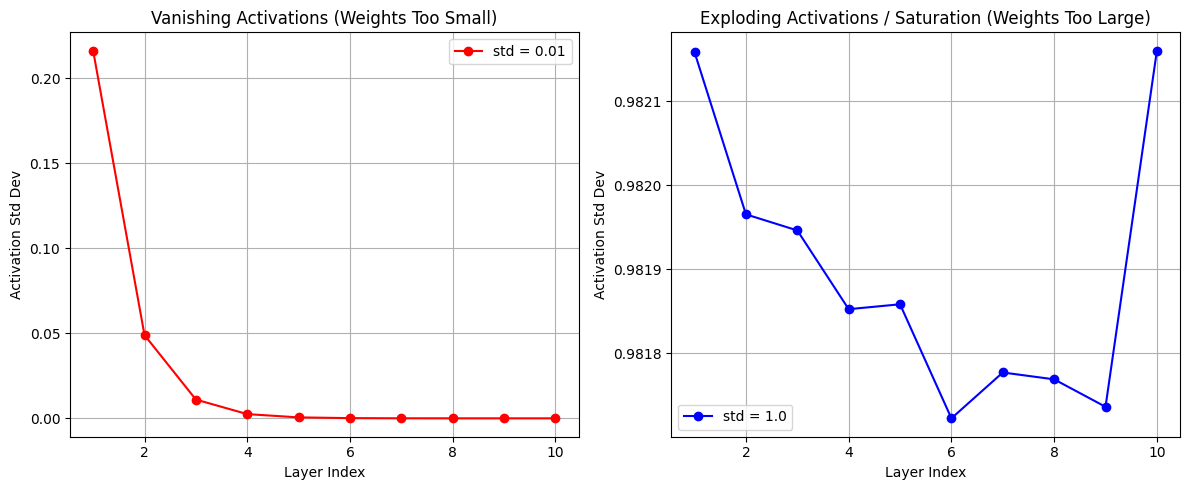

In [22]:
# Create a deep feedforward network with 10 hidden layers
class DeepLinearMLP(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=512, num_layers=10, init_mode='constant', std=0.01):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            in_d = input_dim if i == 0 else hidden_dim
            self.layers.append(nn.Linear(in_d, hidden_dim, bias=False))
            
        # Apply custom initialization based on standard deviation
        for layer in self.layers:
            if init_mode == 'constant':
                nn.init.normal_(layer.weight, mean=0.0, std=std)
            
    def forward(self, x):
        activations = []
        out = x
        for layer in self.layers:
            out = torch.tanh(layer(out))
            activations.append(out.detach())
        return activations

# Generate high-dimensional random input with variance 1
x_init = torch.randn(1000, 512)  # 1000 samples, 512 features

# 1. Weights initialized too small (std = 0.01)
model_small = DeepLinearMLP(init_mode='constant', std=0.01)
activations_small = model_small(x_init)

# 2. Weights initialized too large (std = 1.0)
model_large = DeepLinearMLP(init_mode='constant', std=1.0)
activations_large = model_large(x_init)

# Let's plot the standard deviations at each layer
stds_small = [act.std().item() for act in activations_small]
stds_large = [act.std().item() for act in activations_large]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), stds_small, marker='o', color='red', label='std = 0.01')
plt.xlabel('Layer Index')
plt.ylabel('Activation Std Dev')
plt.title('Vanishing Activations (Weights Too Small)')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), stds_large, marker='o', color='blue', label='std = 1.0')
plt.xlabel('Layer Index')
plt.ylabel('Activation Std Dev')
plt.title('Exploding Activations / Saturation (Weights Too Large)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

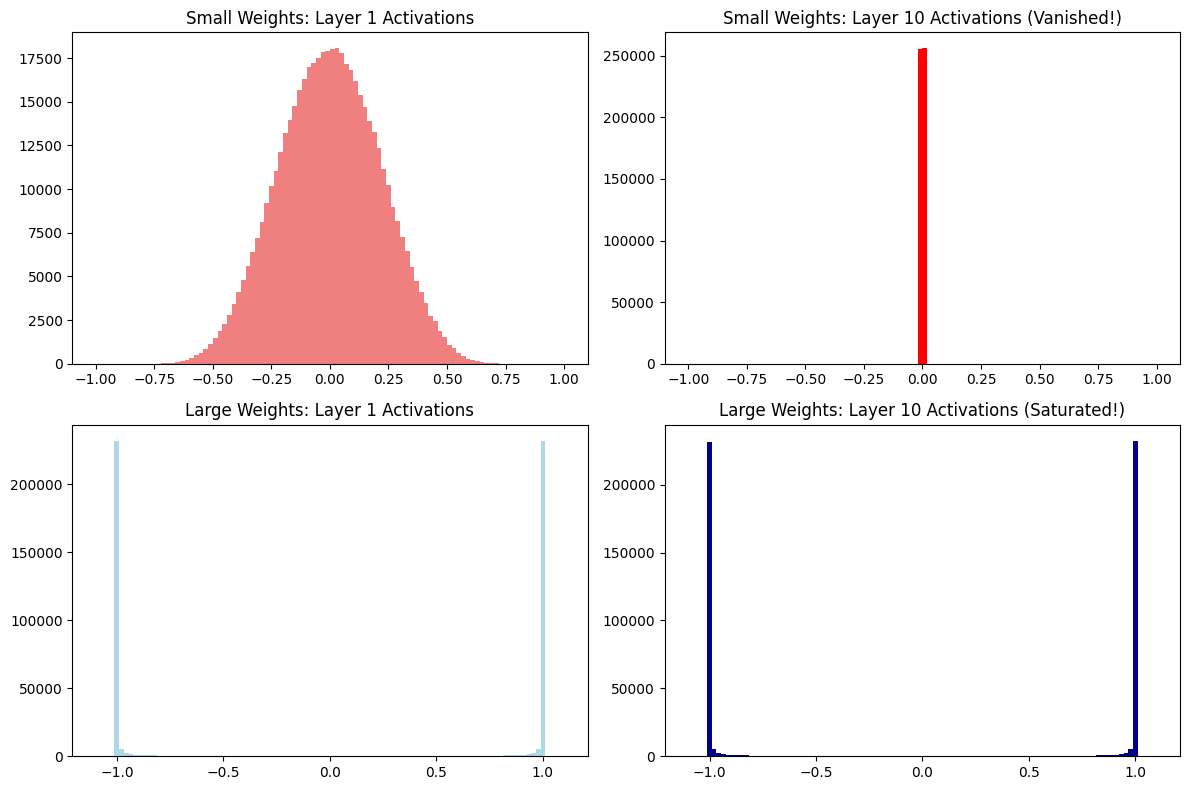

In [23]:
# Let's look at the actual distribution of activations at layer 1 and layer 10
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Row 1: Small Weights
axes[0, 0].hist(activations_small[0].numpy().flatten(), bins=100, color='lightcoral', range=(-1, 1))
axes[0, 0].set_title('Small Weights: Layer 1 Activations')
axes[0, 1].hist(activations_small[9].numpy().flatten(), bins=100, color='red', range=(-1, 1))
axes[0, 1].set_title('Small Weights: Layer 10 Activations (Vanished!)')

# Row 2: Large Weights
axes[1, 0].hist(activations_large[0].numpy().flatten(), bins=100, color='lightblue', range=(-1.1, 1.1))
axes[1, 0].set_title('Large Weights: Layer 1 Activations')
axes[1, 1].hist(activations_large[9].numpy().flatten(), bins=100, color='darkblue', range=(-1.1, 1.1))
axes[1, 1].set_title('Large Weights: Layer 10 Activations (Saturated!)')

plt.tight_layout()
plt.show()

## 3) Xavier (Glorot) Initialization

To prevent the variance of activations from vanishing or exploding as we pass through a feedforward network, **Xavier (Glorot) Initialization** (introduced in 2010 by Xavier Glorot and Yoshua Bengio) aims to keep the variance of the activations and the gradients constant across layers.

For a linear layer with $n_{in}$ input connections and $n_{out}$ output connections, under the assumption of a symmetric activation function around 0 (e.g. Tanh or Sigmoid) and linear behavior near the origin:

### Mathematical formulation

To keep $Var(a^{[l]}) = Var(a^{[l-1]})$, we initialize weights $W$ from a normal distribution:
$$W \sim \mathcal{N}\left(0, \sigma^2\right) \quad \text{where} \quad \sigma = \sqrt{\frac{2}{n_{in} + n_{out}}}$$

Or from a uniform distribution:
$$W \sim \mathcal{U}(-a, a) \quad \text{where} \quad a = \sqrt{\frac{6}{n_{in} + n_{out}}}$$

Let's implement a custom Xavier initialization function and observe its activation distributions using a Tanh activation function.

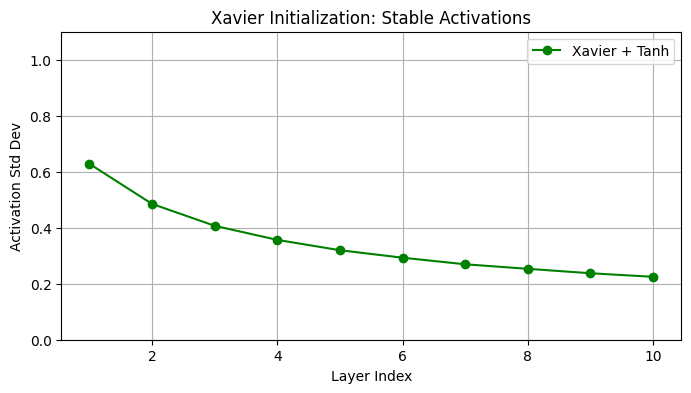

In [24]:
class DeepXavierMLP(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=512, num_layers=10):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            in_d = input_dim if i == 0 else hidden_dim
            self.layers.append(nn.Linear(in_d, hidden_dim, bias=False))
            
        # Apply Xavier Normal Initialization manually
        for layer in self.layers:
            n_in = layer.weight.shape[1]
            n_out = layer.weight.shape[0]
            std = np.sqrt(2.0 / (n_in + n_out))
            nn.init.normal_(layer.weight, mean=0.0, std=std)
            
    def forward(self, x):
        activations = []
        out = x
        for layer in self.layers:
            out = torch.tanh(layer(out))
            activations.append(out.detach())
        return activations

# Forward pass with Xavier initialization on Tanh network
model_xavier = DeepXavierMLP()
activations_xavier = model_xavier(x_init)
stds_xavier = [act.std().item() for act in activations_xavier]

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), stds_xavier, marker='o', color='green', label='Xavier + Tanh')
plt.xlabel('Layer Index')
plt.ylabel('Activation Std Dev')
plt.title('Xavier Initialization: Stable Activations')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()

## 4) He (Kaiming) Initialization

Xavier initialization works exceptionally well for symmetric activation functions like Tanh. However, it fails when using the **Rectified Linear Unit (ReLU)** activation function.

### The ReLU problem
Since ReLU ($f(x) = \max(0, x)$) maps all negative inputs to exactly zero, it essentially **halves** the variance of the activations at each layer. As a result, if we use Xavier initialization with ReLU, the variance will still decay exponentially (by a factor of $0.5$ per layer).

### The Kaiming Solution
In 2015, Kaiming He et al. proposed **He (Kaiming) Initialization**. To compensate for the 50% loss of variance in ReLU, we multiply the variance by 2.

We initialize weights from a normal distribution:
$$W \sim \mathcal{N}\left(0, \sigma^2\right) \quad \text{where} \quad \sigma = \sqrt{\frac{2}{n_{in}}}$$

Or from a uniform distribution:
$$W \sim \mathcal{U}(-a, a) \quad \text{where} \quad a = \sqrt{\frac{6}{n_{in}}}$$

Let's compare Xavier vs. He initializations on a deep network using **ReLU** activations.

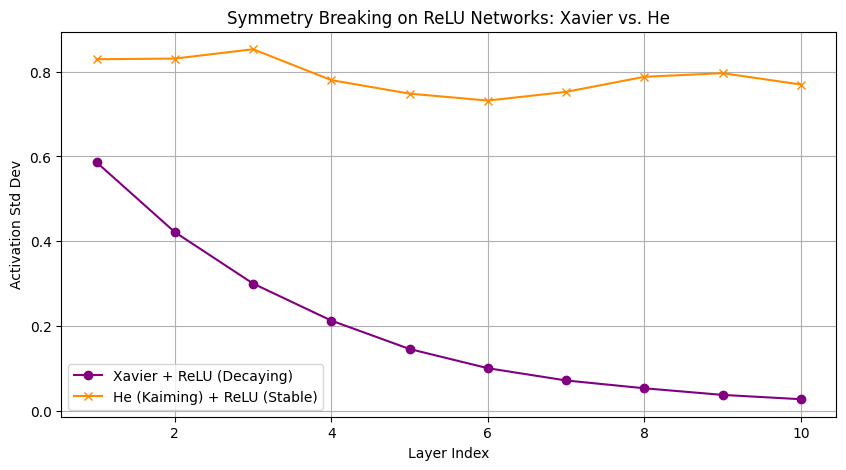

In [25]:
# Deep network using ReLU activations
class DeepReLUMLP(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=512, num_layers=10, init_mode='xavier'):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            in_d = input_dim if i == 0 else hidden_dim
            self.layers.append(nn.Linear(in_d, hidden_dim, bias=False))
            
        # Apply manual initialization
        for layer in self.layers:
            n_in = layer.weight.shape[1]
            n_out = layer.weight.shape[0]
            if init_mode == 'xavier':
                std = np.sqrt(2.0 / (n_in + n_out))
            elif init_mode == 'he':
                # He initialization scales by sqrt(2/n_in)
                std = np.sqrt(2.0 / n_in)
            nn.init.normal_(layer.weight, mean=0.0, std=std)
            
    def forward(self, x):
        activations = []
        out = x
        for layer in self.layers:
            out = F.relu(layer(out))
            activations.append(out.detach())
        return activations

# Forward pass with Xavier vs. He on a ReLU network
model_relu_xavier = DeepReLUMLP(init_mode='xavier')
model_relu_he = DeepReLUMLP(init_mode='he')

activations_relu_xavier = model_relu_xavier(x_init)
activations_relu_he = model_relu_he(x_init)

stds_relu_xavier = [act.std().item() for act in activations_relu_xavier]
stds_relu_he = [act.std().item() for act in activations_relu_he]

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), stds_relu_xavier, marker='o', color='purple', label='Xavier + ReLU (Decaying)')
plt.plot(range(1, 11), stds_relu_he, marker='x', color='darkorange', label='He (Kaiming) + ReLU (Stable)')
plt.xlabel('Layer Index')
plt.ylabel('Activation Std Dev')
plt.title('Symmetry Breaking on ReLU Networks: Xavier vs. He')
plt.grid(True)
plt.legend()
plt.show()

## 5) Implementing Initialization in PyTorch

PyTorch provides a suite of robust initialization utilities within `torch.nn.init`. Instead of writing mathematical variance calculations manually, we should use these pre-defined methods.

### Key Functions
- `nn.init.xavier_normal_(tensor, gain=1.0)`
- `nn.init.xavier_uniform_(tensor, gain=1.0)`
- `nn.init.kaiming_normal_(tensor, a=0, mode='fan_in', nonlinearity='relu')`
- `nn.init.kaiming_uniform_(tensor, a=0, mode='fan_in', nonlinearity='relu')`

The `gain` parameter (for Xavier) and the `a` parameter (for leaky ReLU slope in Kaiming) adjust the initialization scale based on the activation function.

Let's see how to write a reusable initialization function and apply it to a PyTorch model.

In [26]:
class CustomNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )
        # Apply the initialization
        self.apply(self._init_weights)
        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            # Apply Kaiming initialization to weights
            nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            # Initialize biases to a small constant or zero
            if module.bias is not None:
                nn.init.constant_(module.bias, 0.01)

model_custom = CustomNetwork()
print("Model structure:\n", model_custom)
print("\nFirst layer weights sample:\n", model_custom.features[0].weight[:2, :5])

Model structure:
 CustomNetwork(
  (features): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)

First layer weights sample:
 tensor([[ 0.6629,  0.3283,  0.1366, -0.0166,  0.2540],
        [ 0.4911, -0.0059, -0.2783,  0.1395, -0.4163]],
       grad_fn=<SliceBackward0>)


## 6) Training Comparison: Converging vs. Stalled Networks

Now let's run a complete experiment. We will generate a synthetic classification dataset, define a 5-layer MLP, and train it under 5 different initialization strategies:
1. **Zero Initialization**: Expecting the network to stall or perform poorly due to symmetry issues.
2. **Tiny Random Initialization** (std = 0.005): Expecting vanishing gradients.
3. **Exploding Random Initialization** (std = 1.0): Expecting gradient explosion/saturation.
4. **Xavier Normal Initialization** (using Tanh activation).
5. **He Normal Initialization** (using ReLU activation).

We will track training loss and test accuracy across epochs to observe the differences.

In [27]:
# Generate synthetic dataset: 2000 samples, 20 features, 3 classes
X, y = make_classification(n_samples=2000, n_features=20, n_classes=3, n_informative=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# Standard MLP model structure
class MLP(nn.Module):
    def __init__(self, act_fn='relu', init_mode='he', std=0.01):
        super().__init__()
        self.fc1 = nn.Linear(20, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 3)
        self.act_fn = act_fn
        
        # Apply initializations
        self.init_weights(init_mode, std)
        
    def init_weights(self, mode, std):
        for layer in [self.fc1, self.fc2, self.fc3, self.fc4]:
            if mode == 'zero':
                nn.init.zeros_(layer.weight)
            elif mode == 'random':
                nn.init.normal_(layer.weight, mean=0.0, std=std)
            elif mode == 'xavier':
                nn.init.xavier_normal_(layer.weight)
            elif mode == 'he':
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)
                
    def forward(self, x):
        act = torch.tanh if self.act_fn == 'tanh' else F.relu
        x = act(self.fc1(x))
        x = act(self.fc2(x))
        x = act(self.fc3(x))
        return self.fc4(x)

# Training loop utility
def train_model(init_mode, act_fn='relu', std=0.01, epochs=100):
    model = MLP(act_fn=act_fn, init_mode=init_mode, std=std).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    accuracies = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_t)
            test_loss = criterion(test_outputs, y_test_t)
            preds = test_outputs.argmax(dim=1)
            accuracy = (preds == y_test_t).float().mean().item()
            
        losses.append(loss.item())
        accuracies.append(accuracy)
        
    return losses, accuracies

# Run experiments
results = {}
epochs = 50
print("Training models...")
results['Zero Init'] = train_model('zero', act_fn='relu', epochs=epochs)
results['Tiny Random (std=0.005)'] = train_model('random', act_fn='relu', std=0.005, epochs=epochs)
results['Exploding (std=1.0)'] = train_model('random', act_fn='relu', std=1.0, epochs=epochs)
results['Xavier + Tanh'] = train_model('xavier', act_fn='tanh', epochs=epochs)
results['He (Kaiming) + ReLU'] = train_model('he', act_fn='relu', epochs=epochs)
print("Training complete!")

Training models...
Training complete!


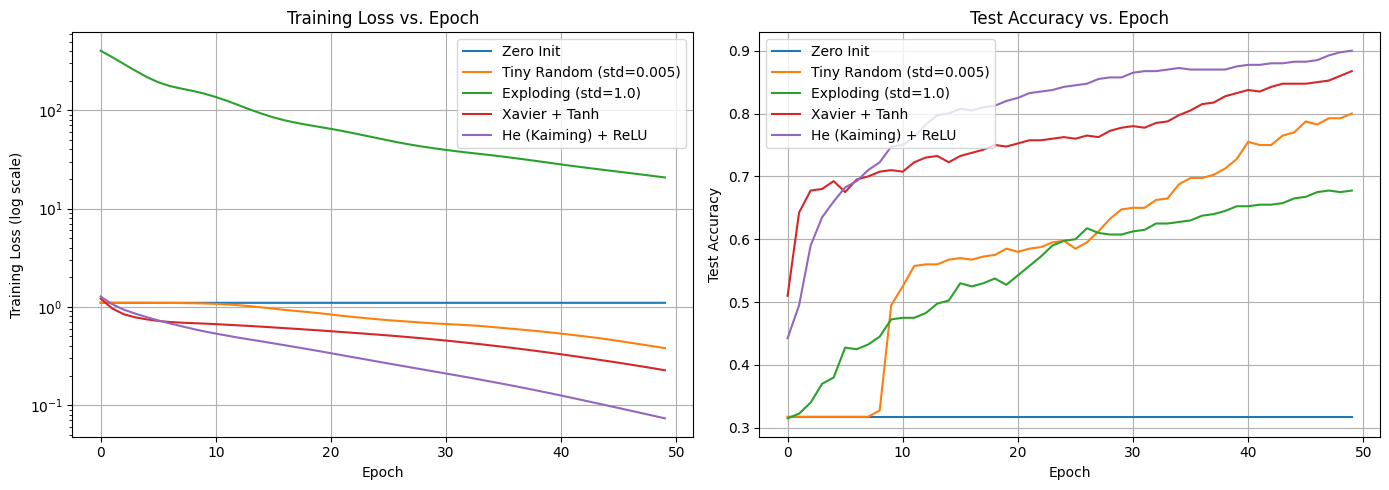

In [28]:
# Plot training loss
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
for name, (losses, _) in results.items():
    plt.plot(losses, label=name)
plt.xlabel('Epoch')
plt.ylabel('Training Loss (log scale)')
plt.yscale('log')
plt.title('Training Loss vs. Epoch')
plt.grid(True)
plt.legend()

# Plot test accuracy
plt.subplot(1, 2, 2)
for name, (_, accs) in results.items():
    plt.plot(accs, label=name)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy vs. Epoch')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## 7) Summary & Best Practices

Weight initialization determines whether your network starts with healthy gradient flow or immediately gets stuck.

### Quick Reference Guide

| Activation Function | Recommended Initialization | PyTorch function |
| --- | --- | --- |
| **Sigmoid / Tanh** | Xavier (Glorot) | `nn.init.xavier_normal_` or `nn.init.xavier_uniform_` |
| **ReLU / LeakyReLU** | He (Kaiming) | `nn.init.kaiming_normal_` or `nn.init.kaiming_uniform_` |
| **Linear / Output** | Xavier (Glorot) | `nn.init.xavier_normal_` |

### Key takeaways:
1. **Always Break Symmetry**: Never initialize weights to constants or zeroes (unless it is biases, where zero init is standard).
2. **Scale with Layer size**: The variance of initialized weights must scale inversely with the number of input units ($n_{in}$) to prevent activations from exploding or vanishing.
3. **Use standard initializations**: Kaiming/He and Xavier are mathematically optimized defaults. Prefer them over manual standard deviation tuning.